##task 1

1. Veriyi hazırla ve tabanı kur. Tiny Shakespeare'i oku, karakter tokenizer'ını yaz (encode, decode), veriyi %90 train, %10 val diye ayır. Rastgele parçalardan batch çeken get_batch fonksiyonunu yaz. Hafta 2'deki bigram modelini nn.Module olarak kur, eğit, val loss'u kaydet. Bu senin karşılaştırma tabanın. (7:52 - 38:00)

In [3]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-10-02 12:02:49--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-10-02 12:02:49 (20.0 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [4]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
  text = f.read()

In [5]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [6]:
# buradan sonra char to int ve int to char mapping yapacagiz

In [7]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # stringi  sayilara encode ediyoruz
decode = lambda l: ''.join([itos[i] for i in l]) # sayilari stringde decode ediyoruz, harf harf gitmek yerine direkt tum string uzreinde islem yapiliyor


print(encode("hii there"))
print(decode(encode("hii there")))


[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [8]:
# tum dataseti encode edelim
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # ilk 1000 karakter boyle gozukuyor not: burada tokenizing islemi character-level. Google veya openai in tiktoken veya sentencepiece gibi tokenizerlari
# sub-word levelda calisiyor ve vocablary character levela kiyasla cok daha buyuk

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [141]:
# dataset parsing, 90 train icin 10 validation icin
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]
# not: normalde bu datayi shuffle etmek gerekirdi diye dusunuyorum dogrulugunu kontrol edecegim

# #Asıl dikkat edilecek nokta: bölme rastgele değil, ardışık.
#   İlk %90 train, son %10 val. Karakter dizisini rastgele karıştırsaydı, birbirine bindirmeli bloklar yüzünden train'de gördüğü metin parçaları
#   val'de de yer alırdı. Böylece val loss sahte biçimde düşük çıkardı. Ardışık bölme bu sızıntıyı önlüyor.

#   Ödev açısından: Sadece mimariyi kurup eğitiyorsan 90/10 yeterli. Ama birkaç konfigürasyonu karşılaştırıp "en iyisi şu, kaybı X" diye rapor
#   edeceksen, ayrı bir test parçası ayırman gerekir. Yoksa raporladığın X iyimser çıkar.

#   result: Karpathy'nin GPT videosunda test setini atlamasının nedeni, raporlayacağı bir nihai performans iddiası olmaması; overfit takibi için
#   val, modelin iyi olup olmadığına bakmak için de üretilen örnekler yetiyor. Bölmenin rastgele değil ardışık olması ise veri sızıntısını
#   önlüyor.


# AYRICA test split olmamasinin sebebi modelin gercek performansi 3. parti benchmarklar tarafindan olculdugu icin test splite ihtiyac duyulmamis.
# burada sadece val lossa gore hiperparametreleri ayarlayarak modelin overfit olmasini engellemek

In [142]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [143]:
x = train_data[:block_size]
y = train_data[1:block_size+1] # y, x'in bir saga kaydirilmis hali yani y[t] her zaman x[t]'den sonra gelen karakteri temsil ediyor.


for t in range(block_size):
    context = x[:t+1]
    # NOT!!!!! eger context = x[t] olsaydi bu sefer olusturdugumuz model bigram modelin aynisi olurdu. Burada yavastan attentiona geciyoruz.
    # Somut örnek
  # Son karakter e ise sonra ne gelir? r, n,  , s, a... Neredeyse her şey olabilir.
  # Ama bağlam "to b" ise sonraki karakter büyük ihtimalle e.
  # Tahmin için gereken bilgi geçmişin içinde. Tek karakter bunu taşımaya yetmiyor.
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [144]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53

In [16]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

eval_iters = 200
eval_interval = 300
max_iters =3000
batch_size = 32

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
      logits = self.token_embedding_table(idx) # (B,T,C)

      if targets is None:
            loss = None

      else:
          # idx and targets are both (B,T) tensor of integers

        B, T, C = logits.shape
        logits = logits.view(B*T, C) # pytorch maalesef ki B,T,C gorunumune izin vermedigi icin B,C formuna ceviriyoruz
        targets = targets.view(B*T) # bundada ayni sekilde
        loss = F.cross_entropy(logits, targets) # NLL loss

      return logits,loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

m = BigramLanguageModel(vocab_size)
logits,loss = m(xb,yb)
print(logits.shape) # gecen hafta konustugumuz B,T,C shapei  batch,time,channel ya da batch,block_size,oznitelik sayisi da diyebiliriz
print(loss)

idx =torch.zeros((1, 1), dtype=torch.long) # torch.zeros olmasinin sebebi yeni sequence baslarken space ile baslatmak istememiz
print(decode(m.generate(idx, max_new_tokens=100)[0].tolist())) # space karakteri ile basla 100 token uret ve hepsini listeye alip decode et.

NameError: name 'xb' is not defined

In [146]:
@torch.no_grad()
def estimate_loss(): # val loss icin ortalamayi almamiz gerekiyor cunku batch kucuk oldugu icin loss cok noisy cikiyor gecen hafta yapmistik
  out = {}
  m.eval()
  for split in ['train', 'val']:
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
      X, Y = get_batch(split)
      logits, loss = m(X, Y)
      losses[k] = loss.item()
    out[split] = losses.mean()
  m.train()
  return out

In [147]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3) # SGD yerine daha gelismis bir optimizer

In [148]:
for iter in range(10000):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long)
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))

step 0: train loss 4.7296, val loss 4.7235
step 300: train loss 4.3767, val loss 4.3844
step 600: train loss 4.0784, val loss 4.0838
step 900: train loss 3.8092, val loss 3.8103
step 1200: train loss 3.5729, val loss 3.5832
step 1500: train loss 3.3816, val loss 3.3900
step 1800: train loss 3.2193, val loss 3.2273
step 2100: train loss 3.0785, val loss 3.0809
step 2400: train loss 2.9584, val loss 2.9731
step 2700: train loss 2.8726, val loss 2.8846
step 3000: train loss 2.7959, val loss 2.8045
step 3300: train loss 2.7426, val loss 2.7433
step 3600: train loss 2.6890, val loss 2.7012
step 3900: train loss 2.6533, val loss 2.6584
step 4200: train loss 2.6169, val loss 2.6289
step 4500: train loss 2.6066, val loss 2.6003
step 4800: train loss 2.5727, val loss 2.5888
step 5100: train loss 2.5594, val loss 2.5539
step 5400: train loss 2.5311, val loss 2.5491
step 5700: train loss 2.5293, val loss 2.5324
step 6000: train loss 2.5165, val loss 2.5252
step 6300: train loss 2.5102, val loss 2

In [149]:
# BIGRAM LANGUAGE MODEL ILE VAL LOSSUMUZ 2.5 CIVARI CIKTI VE TASK 1 BITTI!!!!

In [150]:
# inference
print(decode(m.generate(idx, max_new_tokens=500)[0].tolist())) # space karakteri ile basla 100 token uret ve hepsini listeye alip decode et.


PONEToRKE?
ME:
ONRInat sith;

Whelyon:

NGByOR:
Bld,

ONay.
D:
ATheme t d qus se n mid todr, anckyobjul leris s thatorealit;
TESt' ves d Lak sbe ag mand spatastin Whithad tani-d, owoith lieve, pll,

N ay ESe we ththea'd ine ind s :
Beloue he pede f, que, t-bldu aino athe tef horw; h? ere whead thacedefetht panken thon. d bokit tese;

If d, n blerstard,
Al?
BENG IZpare uistw t tonthoney iceanent BRKIthaghatens:
LNALUTI weno myond RIS:
Ledin rond, FIN!
Myod ohey, n ispicereetithin rreanne sthacano


In [151]:
# cikti bigram language model oldugu icin berbat. peki nasil daha iyilestirebiliriz?

##task 2
Geçmişin ortalamasını üç yoldan al: for döngüsüyle, lower triangular matrisle (torch.tril) çarparak, softmax'la. Üçünün aynı sonucu verdiğini torch.allclose ile göster. Matris çarpımının neden ağırlıklı ortalama olduğunu kendi cümlelerinle yaz. (42:13 - 58:26)

In [10]:
# bir tokenin diger eski tokenlar ile iletisim kurmasini nasil saglayabiliriz?
# cevap: ondan once gelen tokenlar ile matematiksel bir isleme sokarak. bu ornekte basit bir ortalama alma islemi ornegi yapalim

torch.manual_seed(1337)
B,T,C = 4,8,2
x = torch.randn(B,T,C)

x.shape


torch.Size([4, 8, 2])

In [153]:
# x[b,t] nin mean{i<=t} x[b,i] olmasini istiyoruz
# daha onceden codeforces cozen kisiler direkt bunun cumulative sum problemi oldugunu anlar.

xbow = torch.zeros(B,T,C)
for b in range(B):
  for t in range(T):
    xprev =x[b,:t+1] # (t,C)
    xbow[b,t] = torch.mean(xprev,0)

In [154]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [155]:
xbow[0]

tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [156]:
# fakat ic ice 2 for loop O(n^2) oldugundan dolayi bu yontem verimli degildir. Onun yerine matrix mul yontemini deneyelim

In [13]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
# karpathy burada a'yi rowwise 1'lerin sayisina bolup agirlik gorevi gorduruyor fakat direkt C'yi de manipule edebiliriz
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
#c = c / torch.sum(a, 1, keepdim=True) # benim yaptigim degisiklik burasi
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [158]:
# for loop ile yaptigimiz xbow ile karsilastiralim

wei = torch.tril(torch.ones(T,T))
xbow2 = wei @ x
xbow2 = xbow2/torch.sum(wei,1,keepdim=True)
torch.allclose(xbow,xbow2)

True

In [15]:
# daha clean bir versiyon istersek softmax kullanarak olasilik dagilimini hesaplayabiliriz

tril = torch.tril(torch.ones(T,T))
wei = torch.zeros(T,T)
wei = wei.masked_fill(tril==0,float('-inf'))
wei = F.softmax(wei,dim=1)

xbow3 = wei @ x
torch.allclose(xbow2,xbow3)

AttributeError: module 'torch.functional' has no attribute 'softmax'

## task 3
Tek bir self-attention head yaz: query, key, value ve pozisyon embedding'i. Bir örnekte ağırlık matrisini (wei) yazdır, bir satırını oku: o token hangi token'lara ne kadar bakıyor. Skorları head_size'ın kareköküne neden böldüğümüzü sayıyla göster: bölmeden ve bölerek softmax çıktısını yan yana koy. (58:26 - 1:19:11)

In [160]:
# okey simdi bir tokenin eski komsulariyla iletisim kanalini kurduk. simdi ise birbirileri ile ne kadar 'alakali' olduguna gore bunlara 'onem' atamak gerekiyor.
# cunku ka.... ile
# ak..... şuan model için aynı vektörlere sahip. Bunu düzeltmemiz gerekiyor

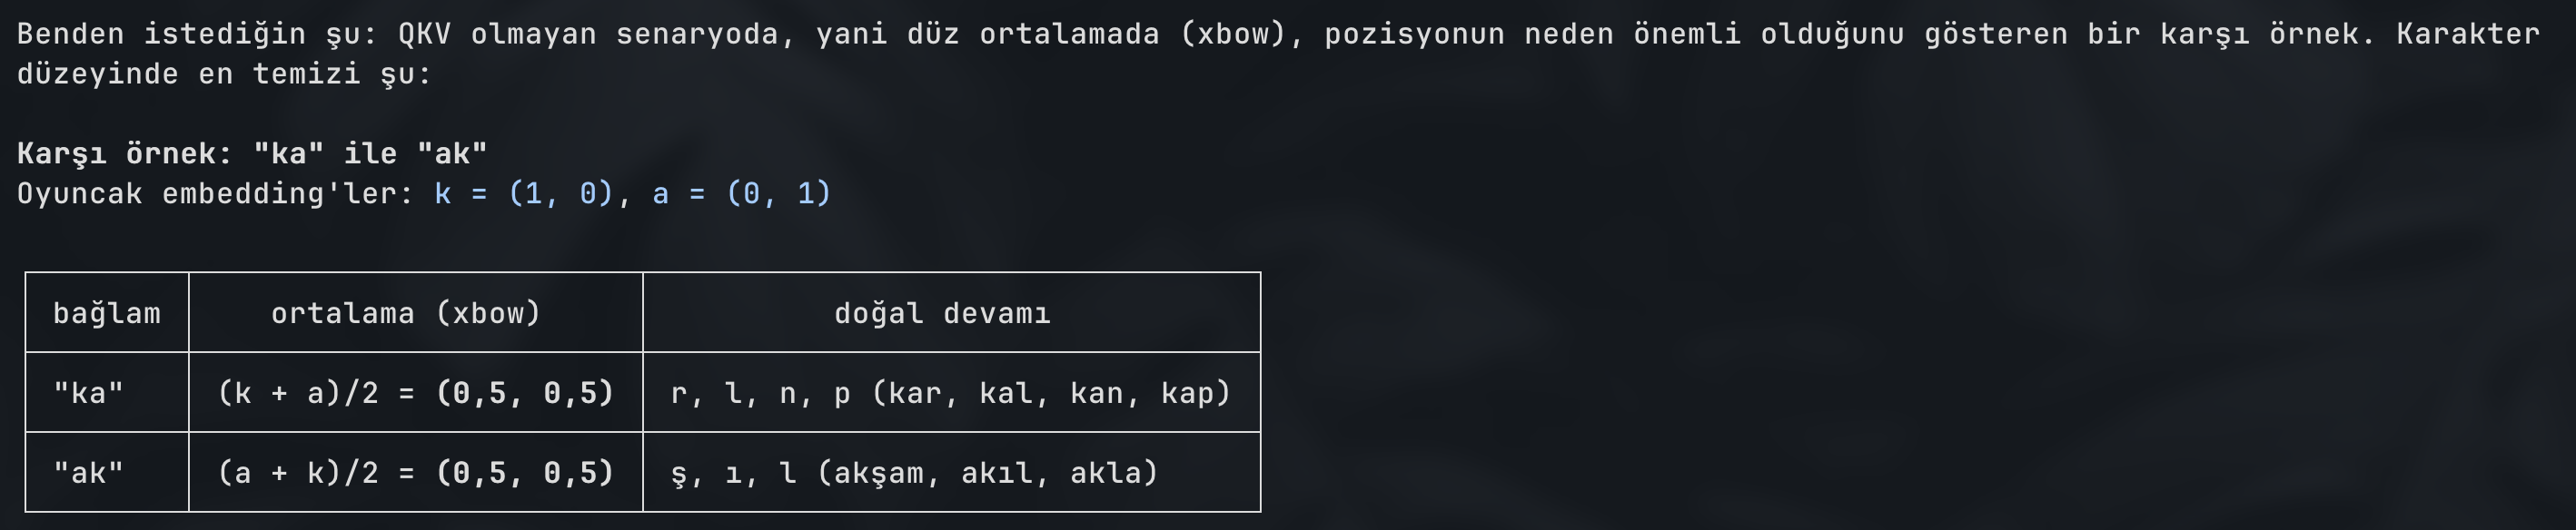

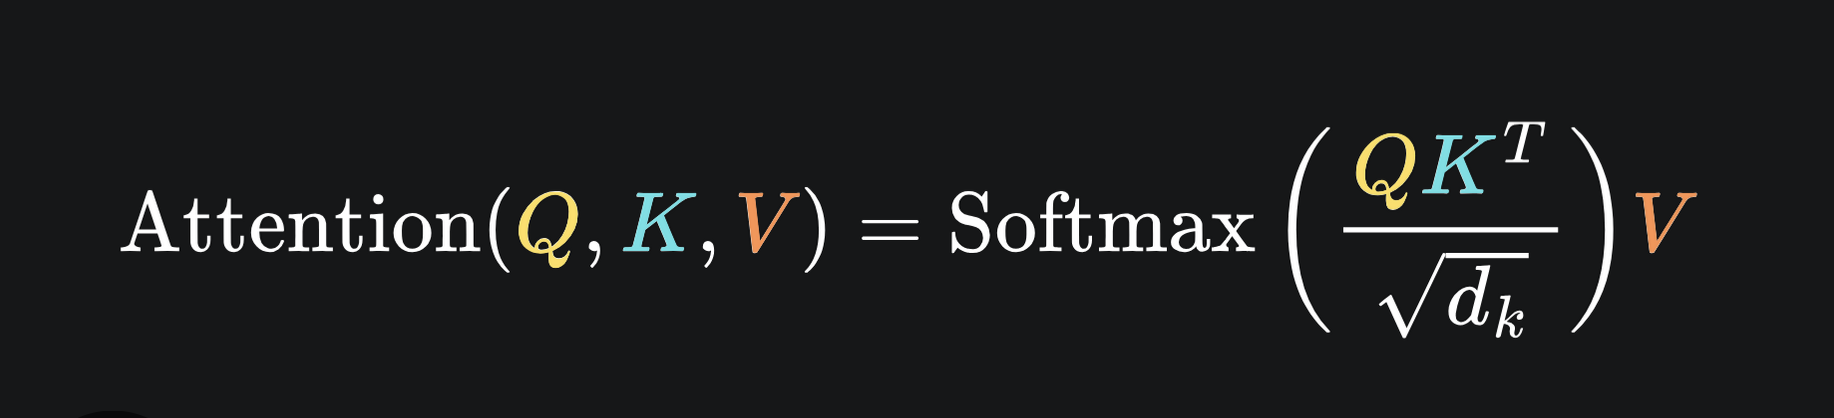

In [167]:
# task2de elde ettigimiz masked wei ciktisi softmaxten gectikten sonra uniform distrubition olusturuyor fakat her kelime birbiriyle esit
# derecede anlamli olmayabilir.
# yukaridaki ornekte 'ka' ile 'ak' daki a'nin ihtiyaci farkli, her token gecmisten neyi ne kadar alacagina icerige bakarak 'karar' vermeli
# bu yuzden her tokena kendisinin ne sundugu K ve bunla overlapini olcmesini saglayacak Q vektoru tanimliyoruz

# kisaca Q: ne aradigim
# K : ne sundugum
# V: secilirsem aktaracagim bilgi
# q.k : overlap skoru



# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False) # ogrenebilir b,t,16 matris
query = nn.Linear(C, head_size, bias=False) #ogrenebilir b,t,16 matris
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1)* head_size **0.5 # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [162]:
wei[0] # karekok head_size ile normalize edilmis hali
# K ve Q sonrasi wei varyansi patladigi icin karekok head_size a bolerek varyansi 1e tekrardan geri indiriyoruz
# boylelikle model diger tokenlara daha smooth bir onem skoru vermis oluyor

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3966, 0.6034, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3069, 0.2892, 0.4039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3233, 0.2175, 0.2443, 0.2149, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1479, 0.2034, 0.1663, 0.1455, 0.3369, 0.0000, 0.0000, 0.0000],
        [0.1259, 0.2490, 0.1324, 0.1062, 0.3141, 0.0724, 0.0000, 0.0000],
        [0.1598, 0.1990, 0.1140, 0.1125, 0.1418, 0.1669, 0.1061, 0.0000],
        [0.0845, 0.1197, 0.1078, 0.1537, 0.1086, 0.1146, 0.1558, 0.1553]],
       grad_fn=<SelectBackward0>)

In [168]:
wei[0] # normalize edilmemis hali


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [164]:
# yukarida yazdigimiz sadece 1 HEAD ornegi. Genelde 1 head yeterli olmadigindan dolayi multi-head katmani kullaniriz. Head, tokenin diger gecmis
# tokenlara karsi sadece 1 soru sorabildigi anlamina geliyor. birden fazla head olursa model sequencelar arasi birden fazla oruntuyu yakalayabilir.

# daha formal bir aciklama:
#Head, az önce yazdığın kodun tamamı: kendine ait bir W_q, W_k, W_v üçlüsüyle tek bir dikkat örüntüsü (wei) üreten birim. Her token bu birimden
  # geçmişe tek bir soru sorabiliyor.

  # Neden "head" denildiği multi-head'e geçince anlaşılıyor
  # Bir head'in wei matrisinde her token için tek bir satır, yani tek bir dağılım var. Bu, bir token'ın geçmişe sadece bir tür soru sorabildiği
  # anlamına geliyor. Ama bir token'ın aynı anda birden fazla şeye ihtiyacı olabilir: "önceki harf ne?", "bu kelime nerede başladı?", "son sesli
  # harf hangisi?".

In [165]:
# B = 1 oldugu durumda teker teker tensorleri inceleyelim simplify etmek adina

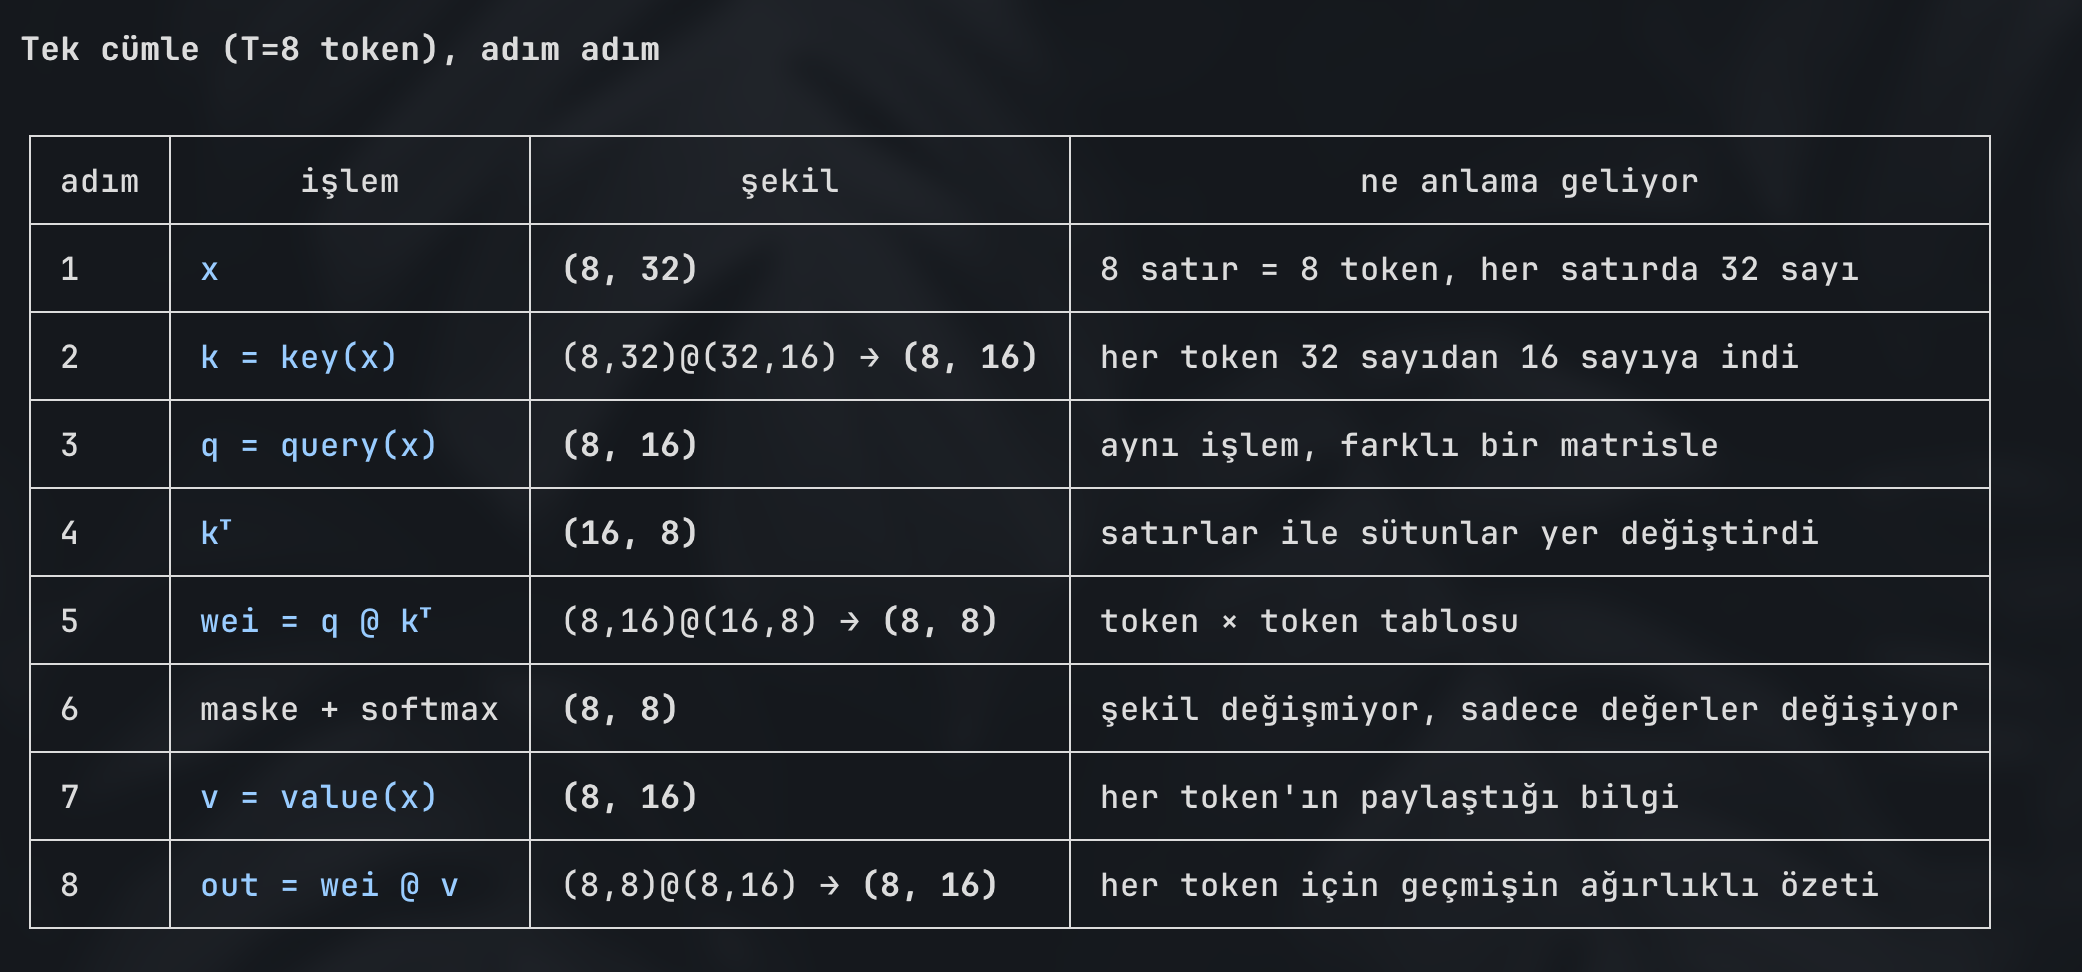

## task 4
Head'i bigram modelinin içine koy ve eğit. Val loss'u 1. görevdeki bigram tabanıyla yan yana koy. Ne kadar düştü, neden düştü, kendi cümlelerinle yaz. Metin üretirken girdiyi neden son block_size harfe kırpmak zorunda olduğunu da yaz. (1:19:11 - 1:21:59)

In [166]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0
# ------------

torch.manual_seed(1337)

# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out
# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.sa_head = Head(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)


    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C) # LEARNED ABSOLUTE
        x = tok_emb + pos_emb # (B,T,C)
        x = self.sa_head(x)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


0.022849 M parameters
step 0: train loss 4.3048, val loss 4.3148
step 100: train loss 2.9305, val loss 2.9525
step 200: train loss 2.7559, val loss 2.7669
step 300: train loss 2.6527, val loss 2.6729
step 400: train loss 2.5717, val loss 2.5836
step 500: train loss 2.5211, val loss 2.5236
step 600: train loss 2.4693, val loss 2.4834
step 700: train loss 2.4450, val loss 2.4619
step 800: train loss 2.4230, val loss 2.4283
step 900: train loss 2.4080, val loss 2.4287
step 1000: train loss 2.4034, val loss 2.4237
step 1100: train loss 2.3929, val loss 2.4059
step 1200: train loss 2.3876, val loss 2.3994
step 1300: train loss 2.3723, val loss 2.3901
step 1400: train loss 2.3668, val loss 2.3887
step 1500: train loss 2.3580, val loss 2.3868
step 1600: train loss 2.3625, val loss 2.3798
step 1700: train loss 2.3436, val loss 2.3653
step 1800: train loss 2.3449, val loss 2.3699
step 1900: train loss 2.3380, val loss 2.3574
step 2000: train loss 2.3289, val loss 2.3693
step 2100: train loss 2.

In [166]:
# headli bigram versiyonunda 2.30
# headsiz bigram da ise 2.50 di


# aradaki fark devasa degil cunku sadece tek katmanli head uyguladik ve bu tek katmanli head sadece geçmiş tokenlar hakkinda 1 dagilima sahip o dagilimda
# sadece 1 attirubute yani 1 soru sormasina izin verebilir
# gundelik modellerde genelde birden fazla katman head olur ve her head farkli attributelari yakalar ornegin isim,zamir yapisini cumle yapisini.
# ne zaman noktalama geleceklerini vs.